In [12]:
# ============================================================
#  HR EMPLOYEE ATTRITION ANALYSIS
#  Phase 1 — Environment Setup & Data Loading
#  Dataset: WA_Fn-UseC_-HR-Employee-Attrition.csv
# ============================================================
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
 
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
 
C_RED   = '#E24B4A'
C_GREEN = '#1D9E75'
C_BLUE  = '#185FA5'
C_ORG   = '#EF9F27'
 
print("=" * 55)
print("  HR EMPLOYEE ATTRITION — PHASE 1: DATA LOADING")
print("=" * 55)

  HR EMPLOYEE ATTRITION — PHASE 1: DATA LOADING


In [13]:
# ── STEP 1: Load dataset ─────────────────────────────────────
df = pd.read_csv('HR Analytics - Predict Employee Attrition.csv')
print(f"\n✅ Dataset loaded")
print(f"   Rows    : {df.shape[0]:,}")
print(f"   Columns : {df.shape[1]}")
 


✅ Dataset loaded
   Rows    : 1,470
   Columns : 35


In [14]:
# ── STEP 2: First look ───────────────────────────────────────
print("\n── Column data types ─────────────────────────────────")
print(df.dtypes.to_string())
 
print("\n── First 3 rows ──────────────────────────────────────")
print(df.head(3).to_string())
 
# ── STEP 3: Null check ───────────────────────────────────────
print("\n── Missing value check ───────────────────────────────")
total_nulls = df.isnull().sum().sum()
if total_nulls == 0:
    print("  ✅ Zero null values — dataset is perfectly clean!")
else:
    print(df.isnull().sum()[df.isnull().sum() > 0])
 


── Column data types ─────────────────────────────────
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64

In [15]:
# ── STEP 4: Identify & drop useless columns ──────────────────
print("\n── Constant columns (zero predictive value) ──────────")
constant_cols = ['EmployeeCount', 'Over18', 'StandardHours']
for col in constant_cols:
    print(f"  {col}: {df[col].unique().tolist()}  ← only 1 unique value")
 
df.drop(constant_cols, axis=1, inplace=True)
print(f"\n✅ Dropped constant columns: {constant_cols}")
 


── Constant columns (zero predictive value) ──────────
  EmployeeCount: [1]  ← only 1 unique value
  Over18: ['Y']  ← only 1 unique value
  StandardHours: [80]  ← only 1 unique value

✅ Dropped constant columns: ['EmployeeCount', 'Over18', 'StandardHours']


In [16]:
 #── STEP 5: Drop ID column ───────────────────────────────────
df.drop('EmployeeNumber', axis=1, inplace=True)
print("✅ Dropped EmployeeNumber (non-predictive ID)")
print(f"   Shape after cleanup: {df.shape}  (1470 rows × 31 cols)")
 

✅ Dropped EmployeeNumber (non-predictive ID)
   Shape after cleanup: (1470, 31)  (1470 rows × 31 cols)


In [17]:
# ── STEP 6: Attrition distribution ───────────────────────────
print("\n── Attrition distribution ────────────────────────────")
counts = df['Attrition'].value_counts()
pcts   = df['Attrition'].value_counts(normalize=True) * 100
print(f"  No  (stayed) : {counts['No']:,}  ({pcts['No']:.1f}%)")
print(f"  Yes (left)   : {counts['Yes']:,}  ({pcts['Yes']:.1f}%)")
print(f"\n  ⚠️  Imbalance ratio: {counts['No']/counts['Yes']:.1f}:1")
print("     → SMOTE required before model training")
 


── Attrition distribution ────────────────────────────
  No  (stayed) : 1,233  (83.9%)
  Yes (left)   : 237  (16.1%)

  ⚠️  Imbalance ratio: 5.2:1
     → SMOTE required before model training


In [18]:
# ── STEP 7: Categorical column overview ──────────────────────
print("\n── Categorical columns ───────────────────────────────")
# Change 'str' to 'object' to correctly select string/text columns
str_cols = df.select_dtypes(include='object').columns.tolist()

if 'Attrition' in str_cols: 
    str_cols.remove('Attrition')

for col in str_cols:
    print(f"  {col:<20} → {df[col].unique().tolist()}")



── Categorical columns ───────────────────────────────
  BusinessTravel       → ['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
  Department           → ['Sales', 'Research & Development', 'Human Resources']
  EducationField       → ['Life Sciences', 'Other', 'Medical', 'Marketing', 'Technical Degree', 'Human Resources']
  Gender               → ['Female', 'Male']
  JobRole              → ['Sales Executive', 'Research Scientist', 'Laboratory Technician', 'Manufacturing Director', 'Healthcare Representative', 'Manager', 'Sales Representative', 'Research Director', 'Human Resources']
  MaritalStatus        → ['Single', 'Married', 'Divorced']
  OverTime             → ['Yes', 'No']


In [19]:
# ── STEP 8: Numeric summary ──────────────────────────────────
print("\n── Key numeric column summary ────────────────────────")
key_cols = ['Age','MonthlyIncome','YearsAtCompany',
            'TotalWorkingYears','DistanceFromHome']
print(df[key_cols].describe().round(1).to_string())
 


── Key numeric column summary ────────────────────────
          Age  MonthlyIncome  YearsAtCompany  TotalWorkingYears  DistanceFromHome
count  1470.0         1470.0          1470.0             1470.0            1470.0
mean     36.9         6502.9             7.0               11.3               9.2
std       9.1         4708.0             6.1                7.8               8.1
min      18.0         1009.0             0.0                0.0               1.0
25%      30.0         2911.0             3.0                6.0               2.0
50%      36.0         4919.0             5.0               10.0               7.0
75%      43.0         8379.0             9.0               15.0              14.0
max      60.0        19999.0            40.0               40.0              29.0


Text(0.5, 0.98, 'Phase 1 — Dataset Overview')

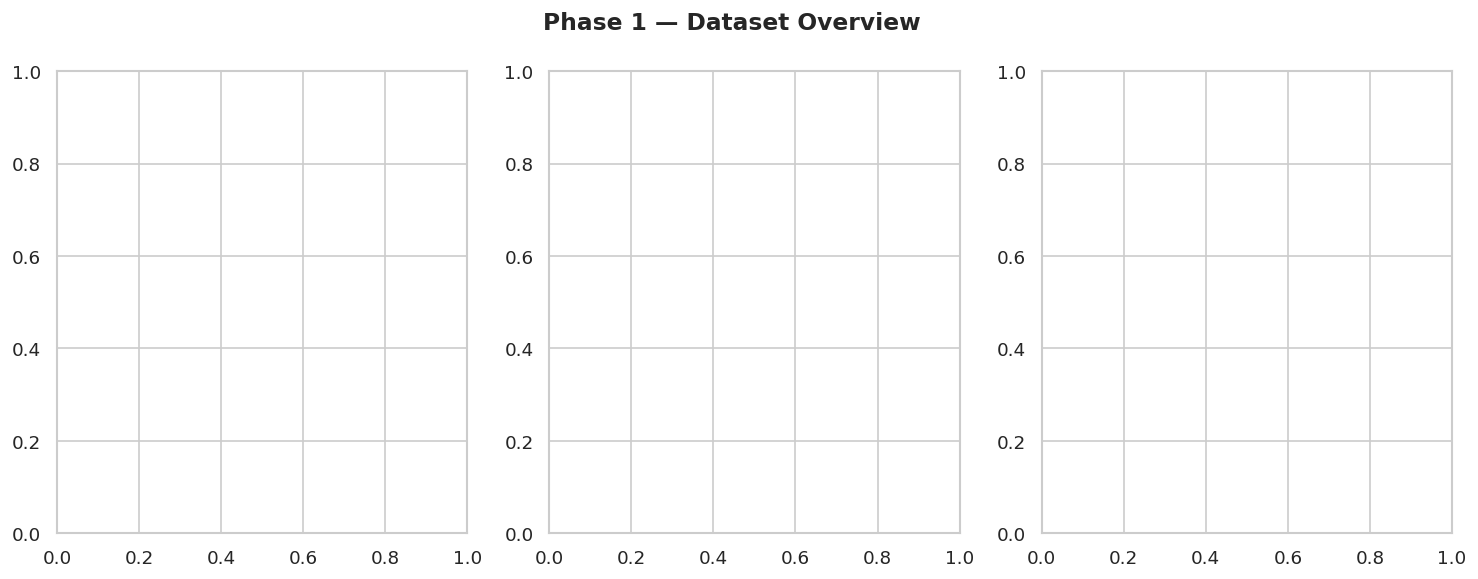

In [20]:
# ── STEP 9: Quick overview chart ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Phase 1 — Dataset Overview', fontsize=14, fontweight='bold')
 

In [21]:
# Attrition pie
axes[0].pie(counts.values,
            labels=[f'Stayed\n({pcts["No"]:.1f}%)', f'Left\n({pcts["Yes"]:.1f}%)'],
            colors=[C_GREEN, C_RED],
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 3})
axes[0].set_title('Attrition Split', fontweight='bold')
 

Text(0.5, 1.0, 'Attrition Split')

In [22]:
# Age distribution
sns.histplot(data=df, x='Age', hue='Attrition',
             palette={'No': C_GREEN, 'Yes': C_RED},
             bins=20, ax=axes[1], alpha=0.75, edgecolor='white')
axes[1].set_title('Age by Attrition', fontweight='bold')
axes[1].axvline(33.6, color=C_RED,   linestyle='--', lw=1.5, label='Left: 33.6')
axes[1].axvline(37.6, color=C_GREEN, linestyle='--', lw=1.5, label='Stayed: 37.6')
axes[1].legend(fontsize=8)
sns.despine(ax=axes[1])

In [23]:
# Monthly income
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df,
            palette={'No': C_GREEN, 'Yes': C_RED},
            ax=axes[2], width=0.5)
axes[2].set_title('Monthly Income by Attrition', fontweight='bold')
for i, attr in enumerate(['No', 'Yes']):
    med = df[df['Attrition'] == attr]['MonthlyIncome'].median()
    axes[2].text(i, med + 100, f'${med:,.0f}', ha='center',
                 fontsize=9, fontweight='bold', color='white',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='#333', alpha=0.75))
sns.despine(ax=axes[2])
 
plt.tight_layout()
plt.savefig('hr_phase1_overview.png', bbox_inches='tight', dpi=150)
plt.show()
print("\n✅ Chart saved: hr_phase1_overview.png")
 

<Figure size 768x576 with 0 Axes>


✅ Chart saved: hr_phase1_overview.png


In [24]:
# ── STEP 10: Save cleaned base ───────────────────────────────
df.to_csv('hr_attrition_cleaned.csv', index=False)
print("✅ Cleaned dataset saved: hr_attrition_cleaned.csv")
 
print("\n" + "=" * 55)
print("  PHASE 1 COMPLETE")
print("=" * 55)
print(f"  Shape       : {df.shape}")
print(f"  Null values : 0")
print(f"  Attrition   : 16.1%  (237 Yes / 1,233 No)")
print(f"  Imbalance   : 5.2:1  → SMOTE needed in Phase 3")
print("\n  → Ready for Phase 2: EDA")

✅ Cleaned dataset saved: hr_attrition_cleaned.csv

  PHASE 1 COMPLETE
  Shape       : (1470, 31)
  Null values : 0
  Attrition   : 16.1%  (237 Yes / 1,233 No)
  Imbalance   : 5.2:1  → SMOTE needed in Phase 3

  → Ready for Phase 2: EDA
